# Notebook 2: Model Training and Evaluation

Notebook 1 established the business context of churn, explored the main customer patterns and highlighted the profiles that appear most exposed to attrition.

This second notebook turns those insights into a reproducible machine learning workflow. The objective is to train, compare, tune and evaluate models that estimate customer-level churn risk.

The resulting model will then be reused in Notebook 3, where the focus shifts from predictive performance to interpretability and actionable retention recommendations.

## 1. Framing the Modeling Task

The business objective is to identify customers who are more likely to churn so that retention efforts can be prioritized before customers leave.

The target variable is `Churn`, converted into a binary outcome:

- `1`: the customer churned
- `0`: the customer did not churn

In practice, the model is not only used to assign a yes/no label. It is also used to rank customers by churn risk, which is more useful when retention resources are limited and outreach cannot be deployed at scale for the full customer base.

A final classification threshold is still needed, but a default value of `0.50` is not necessarily optimal in a churn setting. The appropriate operating point depends on the trade-off between missing churners and contacting customers who would have stayed.

## 2. Imports and Setup

The notebook uses the existing project modules for preprocessing, model training, tuning, saving and evaluation. Notebook-local code is only used for display formatting and compact reporting.

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd

from IPython.display import Image, display

from sklearn.metrics import classification_report

from src.telco_churn.preprocess import (
    load_telco_data,
    split_features_target,
    split_train_test,
    build_preprocessor,
)

from src.telco_churn.train import (
    build_model_pipelines,
    compare_models,
    tune_xgboost,
    save_model,
)

from src.telco_churn.evaluate import (
    find_best_threshold,
    evaluate_classifier,
    plot_confusion_matrix,
)

from src.telco_churn.config import (
    DATA_PATH,
    MODEL_PATH,
    FIGURES_DIR
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## 3. Data Loading and Train/Test Split

The raw dataset is loaded through the project preprocessing module rather than reprocessed manually in the notebook. This ensures consistency with the workflow used throughout the project.

Features and target are reconstructed using the same project utilities and the train/test split is applied before any model comparison or tuning. The test set is then kept untouched until the final evaluation, so that performance is assessed on genuinely unseen data.

In [3]:
df = load_telco_data(DATA_PATH)

X, y = split_features_target(df)
X_train, X_test, y_train, y_test = split_train_test(X, y)

split_summary = pd.DataFrame(
    {
        "rows": [X_train.shape[0], X_test.shape[0]],
        "features": [X_train.shape[1], X_test.shape[1]],
        "churn_rate": [y_train.mean(), y_test.mean()],
    },
    index=["Train", "Test"],
)

print(f"Raw dataset shape: {df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

split_summary

Raw dataset shape: (7043, 21)
Feature matrix shape: (7043, 19)
Target shape: (7043,)


,rows,features,churn_rate
Train,5634,19,0.2654
Test,1409,19,0.2654


The train and test churn rates should remain close because the project split uses stratification. This is important for churn modeling because the positive class is less frequent than the negative class. Without stratification, the test set could accidentally contain a meaningfully different churn rate, making evaluation less reliable.

## 4. Preprocessing Strategy

The preprocessing logic is handled by the existing project functions.

At a high level, the pipeline:

- converts the target into a binary churn indicator
- removes the customer identifier from the feature matrix
- converts `TotalCharges` into a numeric variable
- imputes missing numeric values using the median
- imputes missing categorical values using the most frequent category
- one-hot encodes categorical variables while ignoring unknown categories at inference time

Although missing values are very limited in this dataset, an imputation strategy is retained to ensure robustness to potential missing data in future use cases. An alternative approach based on dropping missing observations was also tested and yielded very similar performance. Given this negligible difference, imputation was preferred as a more general and production-ready solution.

This setup ensures consistent preprocessing and avoids differences between training and inference.

In [4]:
preprocessor = build_preprocessor(X_train)

print("Preprocessor object:")
preprocessor

Preprocessor object:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Model Comparison

Before selecting a final model, two candidates are compared under the same cross-validation setup:

- **Random Forest**
- **XGBoost**, a gradient boosting model well suited for tabular data

Cross-validation provides a more reliable estimate of model quality than a single split.

The comparison focuses on three key metrics:

- **ROC AUC**, which measures how well the model ranks churners above non-churners across thresholds
- **Recall**, which measures how many actual churners are captured
- **Average Precision**, which is especially informative in an imbalanced setting

In a churn context, this reflects the trade-off between identifying at-risk customers and limiting unnecessary interventions. Each candidate is evaluated as a full pipeline, combining preprocessing and modeling under the same validation procedure.

In [5]:
models = build_model_pipelines(X_train, y_train)
comparison = compare_models(models, X_train, y_train)

comparison_display = (
    comparison
    .rename(
        columns={
            "roc_auc": "ROC AUC",
            "recall": "Recall",
            "average_precision": "Average Precision",
        }
    )
    .style
    .format("{:.4f}")
    .background_gradient(cmap="Blues", axis=0)
)

comparison_display

Evaluating Random Forest:
Evaluating XGBoost:


,ROC AUC,Recall,Average Precision
XGBoost,0.8230,0.6462,0.6204
Random Forest,0.8213,0.4957,0.6165


XGBoost performs better than Random Forest across all evaluation metrics and is therefore retained for further tuning.

## 6. Hyperparameter Tuning of the Final Model

The final XGBoost pipeline is tuned using the `tune_xgboost` function based on Random Search, which efficiently explores a subset of the hyperparameter space. Tuning is performed under the same cross-validation framework to ensure consistent evaluation.

In [6]:
xgb_pipeline = models["XGBoost"]

best_xgb = tune_xgboost(xgb_pipeline, X_train, y_train)

best_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [7]:
xgb_model = best_xgb.named_steps["model"]

selected_xgb_params = {
    "n_estimators": xgb_model.get_params().get("n_estimators"),
    "max_depth": xgb_model.get_params().get("max_depth"),
    "learning_rate": xgb_model.get_params().get("learning_rate"),
    "subsample": xgb_model.get_params().get("subsample"),
    "colsample_bytree": xgb_model.get_params().get("colsample_bytree"),
    "scale_pos_weight": xgb_model.get_params().get("scale_pos_weight"),
}

pd.DataFrame(selected_xgb_params, index=["Selected value"]).T

,Selected value
n_estimators,500.0000
max_depth,3.0000
learning_rate,0.0100
subsample,0.7000
colsample_bytree,0.8000
scale_pos_weight,2.7686


The selected parameters above describe the tuned XGBoost model that will be carried forward.

One important detail is `scale_pos_weight`, which helps the model account for the imbalance between churners and non-churners.

## 7. Save the Trained Model

The complete pipeline is saved using the existing project function to ensure it can be reused consistently in the next steps, including the interpretability analysis in Notebook 3.

In [8]:
save_model(best_xgb, MODEL_PATH)

Model saved.


## 8. Threshold Optimization

The tuned model outputs churn probabilities, which must be converted into class predictions using a decision threshold.

While 0.50 is a common default, the optimal threshold depends on the trade-off between precision and recall. In this notebook, the threshold is selected by maximizing the F1-score on the training set, providing a balanced compromise between capturing churners and limiting false positives.

This leads to a slightly higher threshold (0.56), reflecting a balanced decision rule rather than systematically favoring lower thresholds.

In [9]:
best_threshold = find_best_threshold(best_xgb, X_train, y_train)

print(f"Selected threshold based on training data: {best_threshold:.4f}")

Selected threshold based on training data: 0.5606


The selected threshold is applied once on the test set, ensuring a clean evaluation where both the model and threshold are chosen using training data only.

## 9. Final Evaluation on the Test Set

The final evaluation uses the tuned XGBoost pipeline and the selected decision threshold.

The key outputs are:

- ROC AUC and Average Precision, which evaluate probability ranking quality
- the selected threshold, which defines the operating point
- the classification report, which shows precision, recall, and F1-score for both classes

In [10]:
metrics, predictions = evaluate_classifier(
    best_xgb,
    X_test,
    y_test,
    threshold=best_threshold,
)

summary_metrics = pd.DataFrame(
    {
        "Metric": ["ROC AUC", "Average Precision", "Threshold"],
        "Value": [
            metrics["roc_auc"],
            metrics["average_precision"],
            metrics["threshold"],
        ],
    }
)

summary_metrics

,Metric,Value
0,ROC AUC,0.8531
1,Average Precision,0.6618
2,Threshold,0.5606


In [11]:
report_dict = classification_report(
    predictions["y_true"],
    predictions["y_pred"],
    target_names=["No churn", "Churn"],
    output_dict=True,
)

report_table = (
    pd.DataFrame(report_dict)
    .T
    .rename_axis("Class / average")
)

report_table

,precision,recall,f1-score,support
Class / average,,,,
No churn,0.8936,0.7874,0.8372,1035.0000
Churn,0.5573,0.7406,0.6361,374.0000
accuracy,0.7750,0.7750,0.7750,0.7750
macro avg,0.7255,0.7640,0.7366,1409.0000
weighted avg,0.8044,0.7750,0.7838,1409.0000


The model achieves strong ranking performance (ROC AUC ≈ 0.85) and captures around 74% of churners. This comes at the cost of moderate precision, meaning some low-risk customers are still targeted. This reflects a trade-off aligned with churn prevention, where missing a churner can be more costly than unnecessary intervention.

The confusion matrix confirms this trade-off.

Confusion matrix saved.


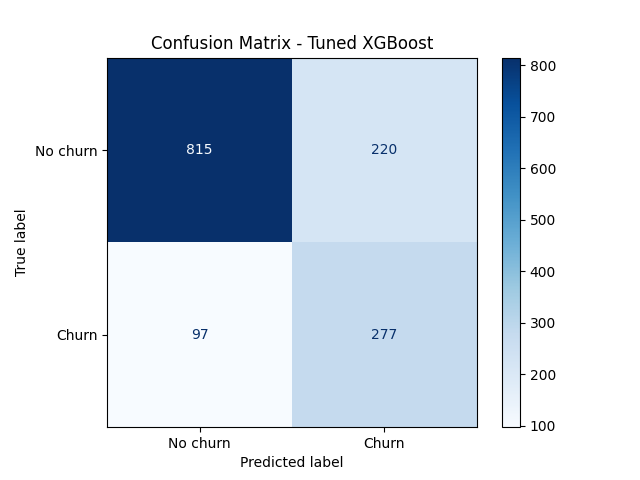

In [12]:
confusion_matrix_path = FIGURES_DIR / "confusion_matrix_tuned_xgb.png"

plot_confusion_matrix(
    y_test,
    predictions["y_pred"],
    save_path=confusion_matrix_path,
)

display(Image(filename=str(confusion_matrix_path)))

## 10. Conclusion

This notebook operationalizes the project’s predictive layer through a structured pipeline that covers preprocessing, model comparison, hyperparameter tuning, threshold optimization and final evaluation.

The emphasis is not only on achieving good predictive performance, but on doing so through a workflow that remains consistent, modular and reusable across the project. The final XGBoost model delivers strong ranking performance and captures a large share of churners, while preserving a clear evaluation discipline through the use of an untouched test set.

Notebook 3 builds on this trained pipeline to examine how the model reaches its predictions and how those outputs can be translated into interpretable and actionable retention signals.